In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import os
import sys
import pickle
import math
import matplotlib

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import func_optimize as fo
from neurolib.utils import costFunctions as cost


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2    

not here


In [2]:
readpath = '..' + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

with open(readpath + os.sep + 'bi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc_granular = load_array[0]
ext_inh_granular = load_array[1]

with open(readpath + os.sep + 'boundary_bi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_exc_granular = load_array[0]
boundary_inh_granular = load_array[1]

grid_resolution = layout.grid_resolution
grid_resolution_granular = layout.grid_resolution_granular

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

facecolor_ = '#EAEAEA'
facecolor_ = 'white'

In [3]:
readpath = '..' + os.sep
savepath = os.path.join(os.getcwd().split('neurolib')[0], 'writing' + os.sep + 'paper1' + os.sep + 'concept' + os.sep + 'images')

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

In [7]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]

def readcase(case_):
    
    global ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low 
    global d_e, d_i, d_total
    global cost_p_x, cost_p_y, cost_s_x, cost_s_y, cost_e_x, cost_e_y
    
    readpath = '..' + os.sep + 'data_final' + os.sep
    
    data_array = data.read_data_1(aln, readpath, case_)
    ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low = data_array
    
    opt_control = [None] * len(ind_)
    opt_state = [None] * len(ind_)
    
    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_state = control_data[3]
        
    d_e = [None] * len(ind_)
    d_i = [None] * len(ind_)
    d_total = [None] * len(ind_)
    
    cost_p_x = [None] * len(ext_exc)
    cost_p_y = [None] * len(ext_exc)
    cost_s_x = [None] * len(ext_exc)
    cost_e_x = [None] * len(ext_exc)
    cost_s_y = [None] * len(ext_exc)
    cost_e_y = [None] * len(ext_exc)
    
    for i in ind_:
        
        if type(opt_control[i]) == type(None):
            continue
    
        if case_ in ['1', '2']:
            d_e[i] = data.dist_right(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_low(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_up_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                                   grid_resolution_granular)
        else:
            d_e[i] = data.dist_left(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_up(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_down_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                               grid_resolution_granular)

        cost_p_x[i] = cost_node[i][0][0][0]
        cost_s_x[i] = cost_node[i][2][0][0]
        cost_e_x[i] = cost_node[i][1][0][0]
        cost_p_y[i] = cost_node[i][0][0][1]
        cost_s_y[i] = cost_node[i][2][0][1]
        cost_e_y[i] = cost_node[i][1][0][1]

In [5]:
##### LOAD BOUNDARIES
with open('boundary_bi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_bi_exc = load_array[0]
boundary_bi_inh = load_array[1]

with open('bi.pickle','rb') as file:
    load_array= pickle.load(file)
bi_exc = load_array[0]
bi_inh = load_array[1]

with open('boundary_LC_granular.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_exc = load_array[0]
boundary_LC_inh = load_array[1]

with open('boundary_LCbi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_up_exc = load_array[0]
boundary_LC_up_inh = load_array[1]


fontsize_ = 32
fontsize_small = 20

case =  ../data_final 1
case =  ../data_final/ 1


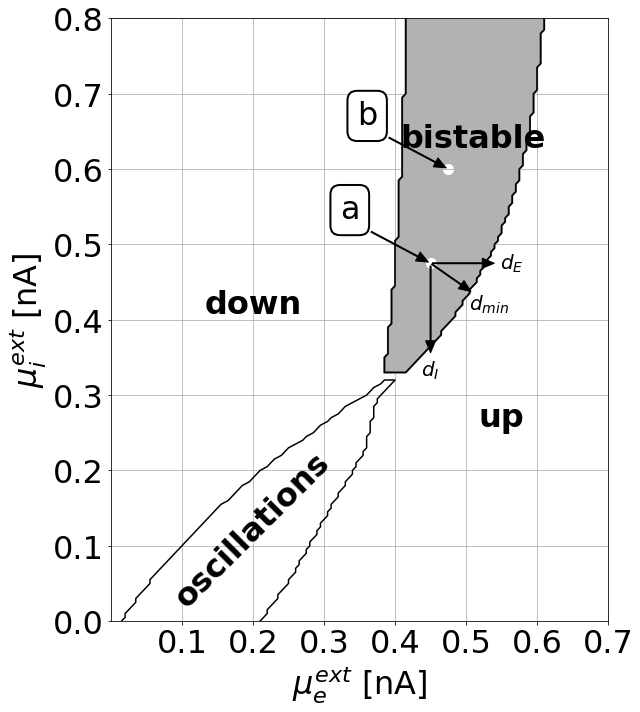

In [9]:

readcase('1') 

fig, ax = plt.subplots(figsize = (9,10), facecolor=facecolor_)
ax.set_ylim(0., .8)
ax.set_xlim(0., .7)
ax.set_xticks(np.arange(0.1, 0.8, 0.1))

vertices = np.zeros(( len(boundary_bi_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_bi_exc[i]
    vertices[i,1] = boundary_bi_inh[i]
path = mpath.Path(vertices)

patch = patches.PathPatch(path, facecolor='grey', alpha=0.6, lw=2)
ax.add_patch(patch)

x, y = zip(*path.vertices)
line, = ax.plot(x, y, markersize=0, color='black')

vertices = np.zeros(( len(boundary_LC_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_LC_exc[i]
    vertices[i,1] = boundary_LC_inh[i]
path = mpath.Path(vertices)
x, y = zip(*path.vertices)
line, = ax.plot(x, y, color='black')

bistable_regime = layout.get_bistable_paths(boundary_bi_exc, boundary_bi_inh)
oscillatory_regime = layout.get_osc_path(boundary_LC_exc, boundary_LC_inh)
LC_up_regime = layout.get_LC_up_path(boundary_LC_up_exc, boundary_LC_up_inh)


x_, y_ = 0.51, 0.62
ax.annotate('bistable', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )
x_, y_ = 0.2, 0.01
ax.annotate('oscillations', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold', rotation=45, zorder=10
        )
x_, y_ = 0.2, 0.4
ax.annotate('down', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )
x_, y_ = 0.55, 0.25
ax.annotate('up', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )
x_ = ext_exc[20]
y_ = ext_inh[20]
ax.plot(x_, y_, 'o', color=facecolor_, markersize=10, zorder=1)
ax.annotate('a', xy=(x_, y_),  xycoords='data',
        xytext=(x_ - 0.1, y_ + 0.05), textcoords='data', fontsize=fontsize_,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom',
        bbox=dict(boxstyle="round,pad=0.3", fc=facecolor_, ec="black", lw=2)
        )
ax.annotate('', xy=(x_ + d_e[20], y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_small,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom'
        )
ax.annotate('', xy=(x_ , y_ - d_i[20]),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_small,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom'
        )
ax.annotate('', xy=(x_ + d_total[20]/np.sqrt(2.) + 0.01, y_ - d_total[20]/np.sqrt(2.) + 0.01),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_small, arrowprops=dict(facecolor='black', shrink=0.03,
        headwidth=10, width=1), horizontalalignment='right', verticalalignment='bottom'
        )
ax.annotate(r'$d_E$', xy=(x_ + d_e[20] + 0.005, y_),  xycoords='data',
        xytext=(x_ + d_e[20] + 0.005, y_), textcoords='data', fontsize=fontsize_small,
        horizontalalignment='left', verticalalignment='center'
        )
ax.annotate(r'$d_I$', xy=(x_, y_ - d_i[20] - 0.005),  xycoords='data',
        xytext=(x_, y_ - d_i[20] - 0.005), textcoords='data', fontsize=fontsize_small,
        horizontalalignment='center', verticalalignment='top'
        )
ax.annotate(r'$d_{min}$', xy=(x_ + d_total[20]/np.sqrt(2.) + 0.005, y_ - d_total[20]/np.sqrt(2.) - 0.005), 
        xycoords='data', xytext=(x_ + d_total[20]/np.sqrt(2.) + 0.005, y_ - d_total[20]/np.sqrt(2.) - 0.005),
        textcoords='data', fontsize=fontsize_small, horizontalalignment='left', verticalalignment='center'
        )
x_ = ext_exc[50]
y_ = ext_inh[50]
ax.plot(x_, y_, 'o', color=facecolor_, markersize=10, zorder=1)
ax.annotate('b', xy=(x_, y_),  xycoords='data',
        xytext=(x_ - 0.1, y_ + 0.05), textcoords='data', fontsize=fontsize_,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom',
        bbox=dict(boxstyle="round,pad=0.3", fc=facecolor_, ec="black", lw=2)
        )

    
ax.set_xlabel(r'$\mu_e^{ext}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$\mu_i^{ext}$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)

fig.tight_layout()
        
plt.savefig(os.path.join(os.getcwd(), 'bifurcation_simple'), bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
plt.savefig(os.path.join(savepath, 'bifurcation_simple'), bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')

In [17]:
readcase('1')

for i in range(len(type_)):
    if type_[i] == 2:
        print(i)
        print(a_e[i])

case =  ../data_final 1
case =  ../data_final/ 1


case =  ../data_final 1
case =  ../data_final/ 1


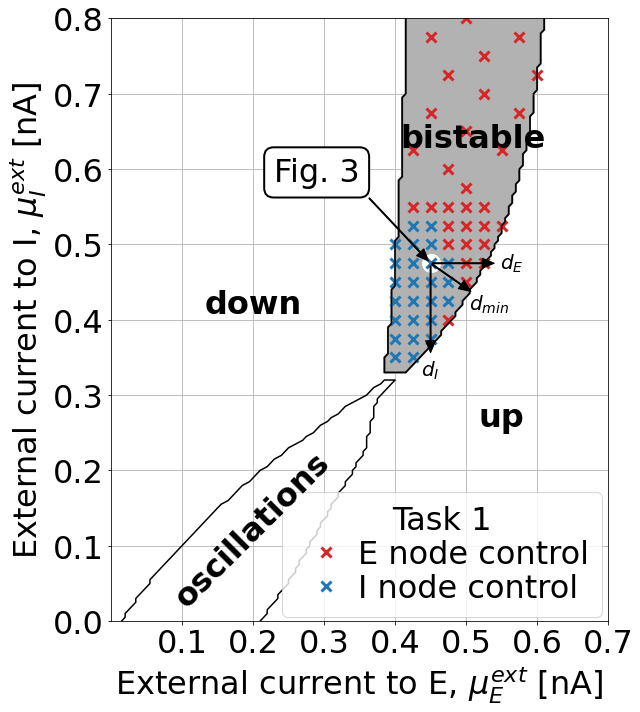

In [7]:
fig1, ax = plt.subplots(figsize = (9,10), facecolor=facecolor_)
ax.set_ylim(0., .8)
ax.set_xlim(0., .7)
ax.set_xticks(np.arange(0.1, 0.8, 0.1))

vertices = np.zeros(( len(boundary_bi_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_bi_exc[i]
    vertices[i,1] = boundary_bi_inh[i]
path = mpath.Path(vertices)

patch = patches.PathPatch(path, facecolor='grey', alpha=0.6, lw=2)
ax.add_patch(patch)
   
ind_x = 0
ind_y = 0

for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_e[i]) > np.abs(a_i[i]):
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=exc_red, markersize=10, markeredgewidth=3)
    else:
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue, markersize=10, markeredgewidth=3)


x, y = zip(*path.vertices)
line, = ax.plot(x, y, markersize=0, color='black')

vertices = np.zeros(( len(boundary_LC_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_LC_exc[i]
    vertices[i,1] = boundary_LC_inh[i]
path = mpath.Path(vertices)
x, y = zip(*path.vertices)
line, = ax.plot(x, y, color='black')

bistable_regime = layout.get_bistable_paths(boundary_bi_exc, boundary_bi_inh)
oscillatory_regime = layout.get_osc_path(boundary_LC_exc, boundary_LC_inh)
LC_up_regime = layout.get_LC_up_path(boundary_LC_up_exc, boundary_LC_up_inh)

x_ = ext_exc[20]
y_ = ext_inh[20]
ax.plot(x_, y_, 'o', color=facecolor_, markersize=18, zorder=1)
ax.annotate('Fig. 3', xy=(x_, y_),  xycoords='data',
        xytext=(x_ - 0.1, y_ + 0.1), textcoords='data', fontsize=fontsize_,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom',
        bbox=dict(boxstyle="round,pad=0.3", fc=facecolor_, ec="black", lw=2)
        )
ax.annotate('', xy=(x_ + d_e[20], y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_small,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom'
        )
ax.annotate('', xy=(x_ , y_ - d_i[20]),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_small,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom'
        )
ax.annotate('', xy=(x_ + d_total[20]/np.sqrt(2.) + 0.01, y_ - d_total[20]/np.sqrt(2.) + 0.01),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_small, arrowprops=dict(facecolor='black', shrink=0.03,
        headwidth=10, width=1), horizontalalignment='right', verticalalignment='bottom'
        )
ax.annotate(r'$d_E$', xy=(x_ + d_e[20] + 0.005, y_),  xycoords='data',
        xytext=(x_ + d_e[20] + 0.005, y_), textcoords='data', fontsize=fontsize_small,
        horizontalalignment='left', verticalalignment='center'
        )
ax.annotate(r'$d_I$', xy=(x_, y_ - d_i[20] - 0.005),  xycoords='data',
        xytext=(x_, y_ - d_i[20] - 0.005), textcoords='data', fontsize=fontsize_small,
        horizontalalignment='center', verticalalignment='top'
        )
ax.annotate(r'$d_{min}$', xy=(x_ + d_total[20]/np.sqrt(2.) + 0.005, y_ - d_total[20]/np.sqrt(2.) - 0.005), 
        xycoords='data', xytext=(x_ + d_total[20]/np.sqrt(2.) + 0.005, y_ - d_total[20]/np.sqrt(2.) - 0.005),
        textcoords='data', fontsize=fontsize_small, horizontalalignment='left', verticalalignment='center'
        )
x_, y_ = 0.51, 0.62
ax.annotate('bistable', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )
x_, y_ = 0.2, 0.01
ax.annotate('oscillations', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold', rotation=45, zorder=10
        )
x_, y_ = 0.2, 0.4
ax.annotate('down', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )
x_, y_ = 0.55, 0.25
ax.annotate('up', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )


legend_elements = [
                   Line2D([], [], color=exc_red, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='E node control'),
                   Line2D([], [], color=inh_blue, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='I node control'),
                      ]


ax.legend(handles=legend_elements, fontsize=fontsize_, title="Task 1", loc='lower right', bbox_to_anchor=(1.02, -0.02), ncol = 1, 
              handletextpad=0., columnspacing=1., labelspacing=0.1)
ax.get_legend().get_title().set_fontsize(fontsize_)
    
ax.set_xlabel(r'$\mu_e^{ext}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$\mu_i^{ext}$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)

fig1.tight_layout()
        
plt.savefig(os.path.join(os.getcwd(), 'FIG_1'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')
plt.savefig(os.path.join(savepath, 'FIG_1'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')

In [67]:
readcase('1')  

case =  ../data_final 1
case =  ../data_final/ 1


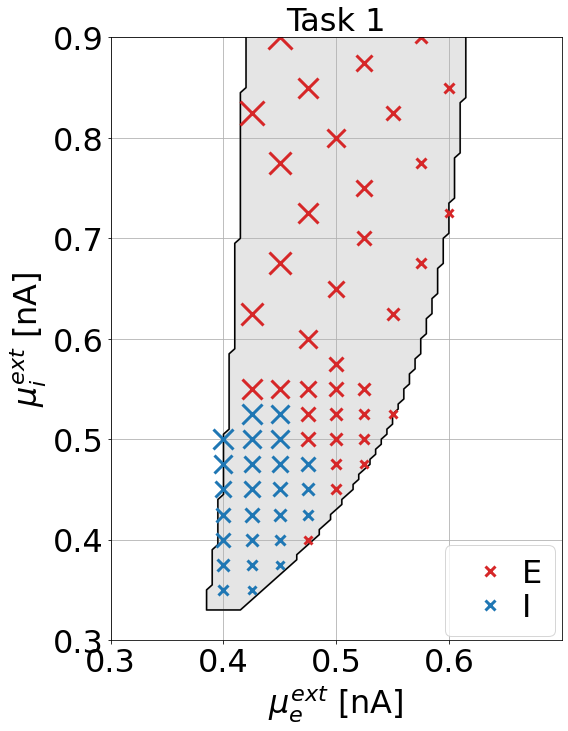

In [68]:
fig1, ax = plt.subplots(figsize = (8,10), facecolor=facecolor_)
ax.set_ylim(0.3, .9)
ax.set_xlim(0.35, .7)
ax.set_xticks(np.arange(0.3, 0.7, 0.1))

vertices = np.zeros(( len(boundary_bi_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_bi_exc[i]
    vertices[i,1] = boundary_bi_inh[i]
path = mpath.Path(vertices)

x, y = zip(*path.vertices)
line, = ax.plot(x, y, markersize=0, color='black')

patch = patches.PathPatch(path, facecolor='grey', alpha=0.2, lw=2)
ax.add_patch(patch)

a_ = []

for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue
    if np.abs(a_e[i]) <= np.abs(a_i[i]):
        a_.append(a_i[i])
    else:
        a_.append(a_e[i])


for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_e[i]) > np.abs(a_i[i]):
        markersize_ = ( np.abs(a_e[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=exc_red, markersize=markersize_*16., markeredgewidth=3)
    else:
        markersize_ = ( np.abs(a_i[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue, markersize=markersize_*16., markeredgewidth=3)


legend_elements = [
                   Line2D([], [], color=exc_red, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='E'),
                   Line2D([], [], color=inh_blue, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='I'),
                      ]


ax.legend(handles=legend_elements, fontsize=fontsize_, loc='lower right', bbox_to_anchor=(1.02, -0.02), ncol = 1, 
              handletextpad=0., columnspacing=1., labelspacing=0.1)
ax.get_legend().get_title().set_fontsize(fontsize_)
    
ax.set_xlabel(r'$\mu_e^{ext}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$\mu_i^{ext}$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)

fig1.tight_layout()
ax.set_title('Task 1', fontsize=fontsize_)
        
plt.savefig(os.path.join(os.getcwd(), 'dimensionality_1'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')
plt.savefig(os.path.join(savepath, 'dimensionality_1'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')

In [69]:
readcase('3')

case =  ../data_final 3
case =  ../data_final/ 3


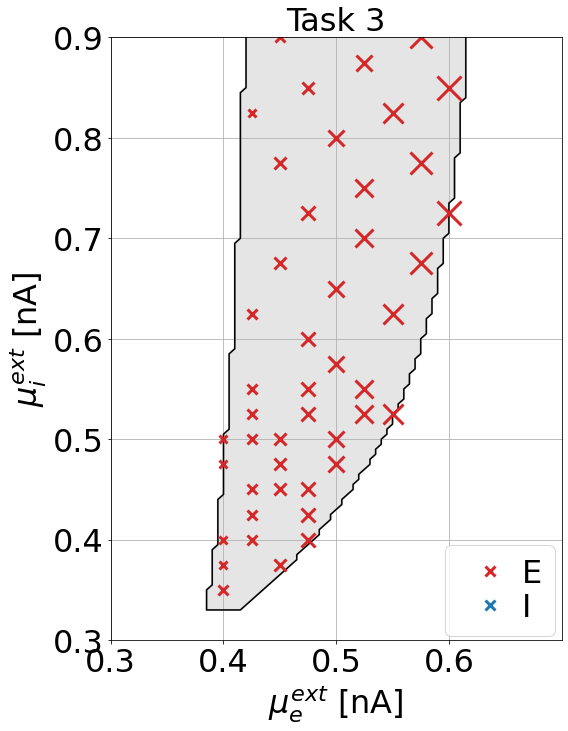

In [70]:
fig1, ax = plt.subplots(figsize = (8,10), facecolor=facecolor_)
ax.set_ylim(0.3, .9)
ax.set_xlim(0.35, .7)
ax.set_xticks(np.arange(0.3, 0.7, 0.1))

vertices = np.zeros(( len(boundary_bi_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_bi_exc[i]
    vertices[i,1] = boundary_bi_inh[i]
path = mpath.Path(vertices)

x, y = zip(*path.vertices)
line, = ax.plot(x, y, markersize=0, color='black')

patch = patches.PathPatch(path, facecolor='grey', alpha=0.2, lw=2)
ax.add_patch(patch)

a_ = []

for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue
    if np.abs(a_e[i]) <= np.abs(a_i[i]):
        a_.append(a_i[i])
    else:
        a_.append(a_e[i])


for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_e[i]) > np.abs(a_i[i]):
        markersize_ = ( np.abs(a_e[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=exc_red, markersize=markersize_*16., markeredgewidth=3)
    else:
        markersize_ = ( np.abs(a_i[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue, markersize=markersize_*16., markeredgewidth=3)


legend_elements = [
                   Line2D([], [], color=exc_red, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='E'),
                   Line2D([], [], color=inh_blue, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='I'),
                      ]


ax.legend(handles=legend_elements, fontsize=fontsize_, loc='lower right', bbox_to_anchor=(1.02, -0.02), ncol = 1, 
              handletextpad=0., columnspacing=1., labelspacing=0.1)
ax.get_legend().get_title().set_fontsize(fontsize_)
    
ax.set_xlabel(r'$\mu_e^{ext}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$\mu_i^{ext}$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)

fig1.tight_layout()
ax.set_title('Task 3', fontsize=fontsize_)
        
plt.savefig(os.path.join(os.getcwd(), 'dimensionality_3'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')
plt.savefig(os.path.join(savepath, 'dimensionality_3'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')

In [76]:
readcase('2')

case =  ../data_final 2
case =  ../data_final/ 2


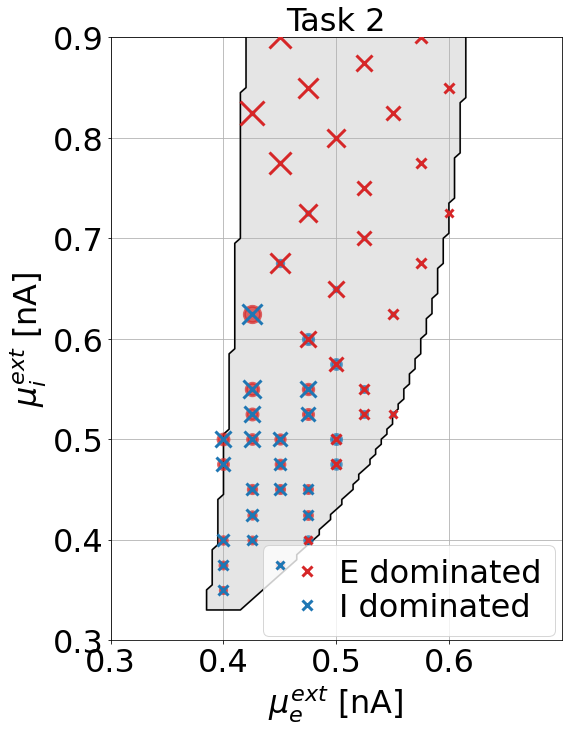

In [88]:
fig1, ax = plt.subplots(figsize = (8,10), facecolor=facecolor_)
ax.set_ylim(0.3, .9)
ax.set_xlim(0.35, .7)
ax.set_xticks(np.arange(0.3, 0.7, 0.1))

vertices = np.zeros(( len(boundary_bi_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_bi_exc[i]
    vertices[i,1] = boundary_bi_inh[i]
path = mpath.Path(vertices)

x, y = zip(*path.vertices)
line, = ax.plot(x, y, markersize=0, color='black')

patch = patches.PathPatch(path, facecolor='grey', alpha=0.2, lw=2)
ax.add_patch(patch)

a_ = []

for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue
    a_.append(a_i[i])
    a_.append(a_e[i])


for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_e[i]) > np.abs(a_i[i]):
        markersize_ = ( np.abs(a_e[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=exc_red, markersize=markersize_*16., markeredgewidth=3, zorder=10)
        markersize_1 = markersize_*16. * np.abs(a_i[i]) / np.abs(a_e[i])
        ax.plot(ext_exc[i], ext_inh[i], 'o', color=inh_blue, markersize=markersize_1, markeredgewidth=3, alpha=0.7)
    else:
        markersize_ = ( np.abs(a_i[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue, markersize=markersize_*16., markeredgewidth=3, zorder=10)
        markersize_1 = markersize_*16. * np.abs(a_e[i]) / np.abs(a_i[i])
        ax.plot(ext_exc[i], ext_inh[i], 'o', color=exc_red, markersize=markersize_1, markeredgewidth=3, alpha=0.7)

legend_elements = [
                   Line2D([], [], color=exc_red, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='E dominated'),
                   Line2D([], [], color=inh_blue, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='I dominated'),
                      ]


ax.legend(handles=legend_elements, fontsize=fontsize_, loc='lower right', bbox_to_anchor=(1.02, -0.02), ncol = 1, 
              handletextpad=0., columnspacing=1., labelspacing=0.1)
ax.get_legend().get_title().set_fontsize(fontsize_)
    
ax.set_xlabel(r'$\mu_e^{ext}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$\mu_i^{ext}$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)

fig1.tight_layout()
ax.set_title('Task 2', fontsize=fontsize_)
        
plt.savefig(os.path.join(os.getcwd(), 'dimensionality_2'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')
plt.savefig(os.path.join(savepath, 'dimensionality_2'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')

In [89]:
readcase('4')

case =  ../data_final 4
case =  ../data_final/ 4


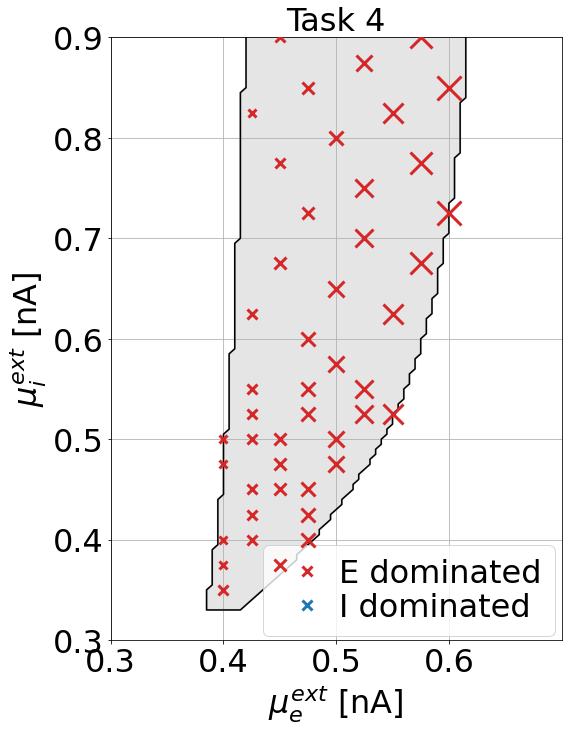

In [92]:
fig1, ax = plt.subplots(figsize = (8,10), facecolor=facecolor_)
ax.set_ylim(0.3, .9)
ax.set_xlim(0.35, .7)
ax.set_xticks(np.arange(0.3, 0.7, 0.1))

vertices = np.zeros(( len(boundary_bi_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_bi_exc[i]
    vertices[i,1] = boundary_bi_inh[i]
path = mpath.Path(vertices)

x, y = zip(*path.vertices)
line, = ax.plot(x, y, markersize=0, color='black')

patch = patches.PathPatch(path, facecolor='grey', alpha=0.2, lw=2)
ax.add_patch(patch)

a_ = []

for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue
    a_.append(a_i[i])
    a_.append(a_e[i])


for i in range(len(ext_exc)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_e[i]) > np.abs(a_i[i]):
        markersize_ = ( np.abs(a_e[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=exc_red, markersize=markersize_*16., markeredgewidth=3, zorder=10)
        markersize_1 = markersize_*16. * np.abs(a_i[i]) / np.abs(a_e[i])
        ax.plot(ext_exc[i], ext_inh[i], 'o', color=inh_blue, markersize=markersize_1, markeredgewidth=3, alpha=0.7)
    else:
        markersize_ = ( np.abs(a_i[i]) - np.amin(np.abs(a_)) ) / ( np.amax(np.abs(a_)) - np.amin(np.abs(a_)) ) + 0.5
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue, markersize=markersize_*16., markeredgewidth=3, zorder=10)
        markersize_1 = markersize_*16. * np.abs(a_e[i]) / np.abs(a_i[i])
        ax.plot(ext_exc[i], ext_inh[i], 'o', color=exc_red, markersize=markersize_1, markeredgewidth=3, alpha=0.7)


legend_elements = [
                   Line2D([], [], color=exc_red, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='E dominated'),
                   Line2D([], [], color=inh_blue, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='I dominated'),
                      ]


ax.legend(handles=legend_elements, fontsize=fontsize_, loc='lower right', bbox_to_anchor=(1.02, -0.02), ncol = 1, 
              handletextpad=0., columnspacing=1., labelspacing=0.1)
ax.get_legend().get_title().set_fontsize(fontsize_)
    
ax.set_xlabel(r'$\mu_e^{ext}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$\mu_i^{ext}$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)

fig1.tight_layout()
ax.set_title('Task 4', fontsize=fontsize_)
        
plt.savefig(os.path.join(os.getcwd(), 'dimensionality_4'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')
plt.savefig(os.path.join(savepath, 'dimensionality_4'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')